In [1]:
import numpy as np
from IQAEBinom import IQAEBinom
import matplotlib.pyplot as plt
import pickle
from BiasCorrection import BiasExact
import datetime

In [2]:
epsilon = 0.001
nEstim = 10000
alpha = 0.05
nShotUnit = 1

In [3]:
p = 0.25

In [4]:
alpha = 0.05 / nEstim
results = np.array([])

for i in range(nEstim):
    result = IQAEBinom(p, epsilon, alpha, nShotUnit, confint_method="chernoff")
    results = np.append(results, result)

KeyboardInterrupt: 

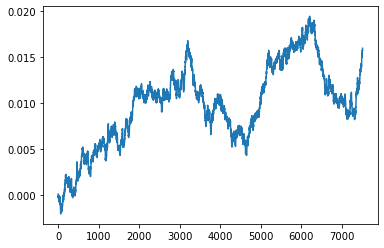

In [6]:
errs = [r["Estimate"] - p for r in results]

ax = plt.gca()
plt.plot(np.array(errs).cumsum())
plt.show()

In [7]:
results[0]

{'Estimate': 0.2500729536156062,
 'TotalOracleCalls': 81792,
 'nGrover': [0, 2, 6, 14, 30, 62, 138, 278],
 'nShots': [1511, 253, 161, 167, 144, 158, 119, 19],
 'n1s': [399, 63, 38, 38, 37, 35, 30, 4],
 'thetaIntervals': [[0, 1.5707963267948966],
  [0.4417444453177239, 0.6281762502031469],
  [0.4833677243380995, 0.5794522661481472],
  [0.4878923946154749, 0.5413143265113335],
  [0.5162807254029191, 0.5393173115404205],
  [0.5174710903167888, 0.5277530747806997],
  [0.5219821217556915, 0.527378388120635],
  [0.5220016715611523, 0.5245353169092889],
  [0.5225288378264188, 0.5245388093067338]],
 'ampSqIntervals': [[0, 1],
  [0.18277087590751684, 0.3453561922592602],
  [0.21600530207733742, 0.2998281911059298],
  [0.21974084536114966, 0.26549581130332595],
  [0.24368938534278323, 0.2637339353525407],
  [0.24471217574725004, 0.2536063162846796],
  [0.24860124592630192, 0.25328035198910365],
  [0.2486181450529206, 0.2508115066474323],
  [0.2490739797994381, 0.2508145344238853]]}

(array([  0.,   0.,   1., 117., 114.,  71.,  72.,  61.,  37.,  32., 113.,
        246., 562., 565., 635., 970., 999., 927., 629., 490., 296., 161.,
        107.,  96.,  63.,  50.,  30.,  20.,  23.,  13.,   4.,   6.,   1.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.]),
 array([100., 110., 120., 130., 140., 150., 160., 170., 180., 190., 200.,
        210., 220., 230., 240., 250., 260., 270., 280., 290., 300., 310.,
        320., 330., 340., 350., 360., 370., 380., 390., 400., 410., 420.,
        430., 440., 450., 460., 470., 480., 490., 500., 510., 520., 530.,
        540., 550., 560., 570., 580., 590., 600., 610., 620., 630., 640.,
        650., 660., 670., 680., 690., 700.]),
 <BarContainer object of 60 artists>)

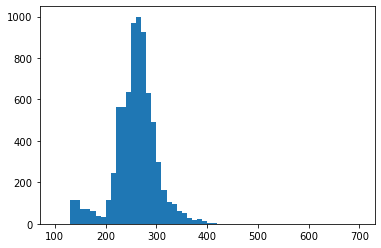

In [8]:
plt.hist([r["nGrover"][-1] for r in results], range=(100,700), bins=60)

(array([  90.,   15.,  103., 1280., 2937., 1079.,  500.,  182.,  154.,
          96.,   95.,   91.,   77.,   71.,   57.,   56.,   44.,   44.,
          39.,   49.,   48.,   44.,   46.,   41.,   42.,   46.,   61.,
          55.,   44.,   20.]),
 array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
         55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
        110., 115., 120., 125., 130., 135., 140., 145., 150.]),
 <BarContainer object of 30 artists>)

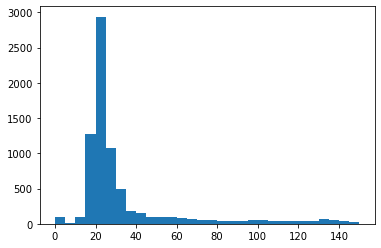

In [9]:
plt.hist([r["nShots"][-1] for r in results], range=(0,150), bins=30)

(array([1.430e+02, 1.098e+03, 2.361e+03, 1.854e+03, 5.390e+02, 2.100e+02,
        1.340e+02, 8.800e+01, 9.400e+01, 1.020e+02, 1.210e+02, 1.030e+02,
        1.070e+02, 8.300e+01, 5.100e+01, 7.300e+01, 6.100e+01, 4.400e+01,
        6.600e+01, 6.100e+01, 9.300e+01, 2.500e+01, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00]),
 array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
         22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
         44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
         66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
         88.,  90.,  92.,  94.,  96.,  98., 100.]),
 <BarContainer object of 50 

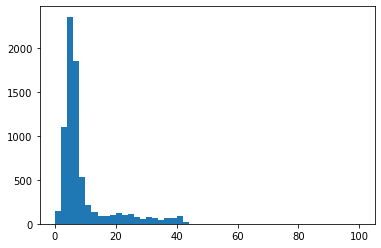

In [10]:
plt.hist([r["n1s"][-1] for r in results], range=(0,100), bins=50)

final p1はunbiasedになってるか？

(array([  0.,   4.,  29.,  66., 103., 201., 310., 379., 467., 444., 730.,
        748., 628., 814., 718., 750., 408., 221., 182.,  77.,  62.,  25.,
         17.,   8.,   5., 114.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]),
 <BarContainer object of 50 artists>)

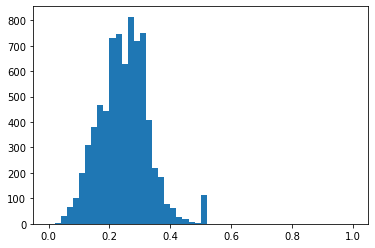

In [11]:
plt.hist([r["n1s"][-1] / r["nShots"][-1] for r in results], range=(0,1), bins=50)

In [13]:
thetaTrue = np.arcsin(np.sqrt(p))
p1FinalErr = [r["n1s"][-1] / r["nShots"][-1] - np.sin((2 * r["nGrover"][-1] + 1) * thetaTrue) ** 2 for r in results]

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   4.,  15.,  13.,  23.,  48.,  40.,  77.,
         79., 113., 120., 180., 203., 199., 203., 241., 216., 334., 264.,
        360., 345., 448., 280., 303., 467., 371., 360., 416., 349., 341.,
        155., 234., 127.,  97., 128.,  51.,  50.,  33.,  39.,  14.,  15.,
         10.,   9.,   8.,   2.,   6.,   5.,  66.,  46.,   2.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([-7.00000000e-01, -6.90000000e-01, -6.80000000e

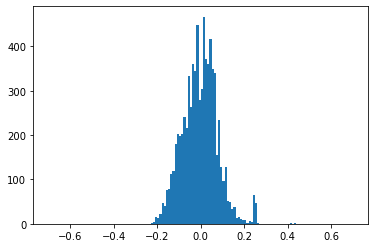

In [14]:
plt.hist(p1FinalErr, range=(-0.7, 0.7), bins=140)

In [15]:
print(np.mean(p1FinalErr))
print(np.std(p1FinalErr) / np.sqrt(len(p1FinalErr)))

-0.003550848767421579
0.0008042391479454802


errorの分布

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   2.,   3.,   4.,  13.,  14.,  17.,  18.,  19.,  32.,
         57.,  57.,  67.,  51., 107.,  88., 134., 161., 162., 260., 380.,
        328., 335., 361., 354., 448., 375., 174., 424., 312., 414., 318.,
        333., 317., 275., 199., 165., 146., 119.,  73.,  83.,  69.,  69.,
         68.,  22.,  25.,   6.,  17.,  13.,   7.,   3.,   3.,   5.,   3.,
          0.,   2.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.]),
 array([-1.0e-03, -9.8e-04, -9.6e-04, -9.4e-04, -9.2e-04, -9.0e-04,
        -8.8e-04, -8.6e-04, -8.4e-04, -8.2e-04, -8.0e-04, -7.8e-04,
        -7.6e-04, -7.4e-04, -7.2e-04, -7.0e-04, -6.8e-04, -6.6e-04,
        -6.4e-04, -6.2e-04, -6.0e-04, -5.8e-04, -5.6e-04, -5.4e-04,
        -5.2e-04, -5.0e-04, -4.8e-04, -4.6e-04

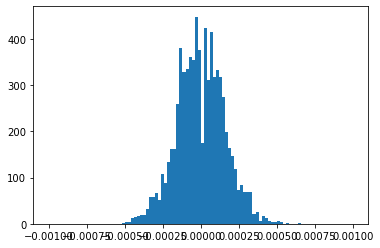

In [16]:
plt.hist(errs, range=(-0.001,0.001), bins=100)